In [2]:
import numpy as np
import bacco

import matplotlib.pyplot as plt
import halotools.mock_observables as ht

In [3]:
%load_ext autoreload
%autoreload 2

In [6]:
base = "/cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/"

sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME

_snap = 264
zoom_snap = bacco.Simulation(basedir=base, halo_file="groups_{:03d}/fof_subhalo_tab_{:03d}".format(_snap,_snap), dm_file="snapdir_{:03d}/snapshot_{:03d}".format(_snap,_snap), sim_format='TNG500', fixedPk=True, use_orphans=False,\
                        tau=tau, ns=ns, sigma8=sigma8, use_ids=False, tree_file="groups_{:03d}/subhalo_prog_{:03d}".format(_snap,_snap), numpart=4320**3)


print(zoom_snap.header['Redshift'])

2026-03-12 18:58:38,923 bacco.sims : Initialising simulation Default
2026-03-12 18:58:38,924 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/snapdir_264/snapshot_264
2026-03-12 18:58:38,926 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/snapdir_264/snapshot_264


2026-03-12 18:58:39,342 bacco.sims : ...done in 0.00864 s


4.440892098500626e-16


In [86]:
def get_profiles(zoom, r_bins, ih, type='dm'):

    hpos = zoom.fof['halo_pos']
    r200 = zoom.fof['halo_r200c']

    _hpos = np.array([hpos[ih]])
    _r200 = np.array([r200[ih]])

    if type=='dm':
        _pos = zoom.dm['pos']
        _mass = np.ones_like(_pos[:,0])  * zoom_snap.header['ParticleMass'] * 1e10
    elif type=='gas':
        _pos = zoom.gas['pos']
        _mass = zoom.gas['mass'] * 1e10
    elif type=='stars':
        _pos = zoom.stars['pos']
        _mass = zoom.stars['mass'] * 1e10
    elif type=='bh':
        _pos = zoom.bh['pos']
        _mass = zoom.bh['mass'] * 1e10

    mask = (_pos[:,0] > _hpos[0,0]-10) & (_pos[:,0] < _hpos[0,0]+10) & \
           (_pos[:,1] > _hpos[0,1]-10) & (_pos[:,1] < _hpos[0,1]+10) & \
           (_pos[:,2] > _hpos[0,2]-10) & (_pos[:,2] < _hpos[0,2]+10)

    y, c = ht.radial_profile_3d(_hpos, _pos[mask], _mass[mask], return_counts=True, rbins_absolute=r_bins)
    rr = 10**((np.log10(r_bins[1:])+np.log10(r_bins[:-1]))*0.5)
    #rr = (rbins[1:]+rbins[:-1])*0.5
    volume = 4 * np.pi / 3 *(r_bins[1:]**3 - r_bins[:-1]**3)

    dens1 = y * c / volume
    x1 = rr

    return x1, dens1

In [87]:
r_dm, rho_dm = get_profiles(zoom_snap, np.logspace(-2, 1, 20), 0, type='dm')
r_gas, rho_gas = get_profiles(zoom_snap, np.logspace(-2, 1, 20), 0, type='gas')
r_stars, rho_stars = get_profiles(zoom_snap, np.logspace(-2, 1, 20), 0, type='stars')
r_bh, rho_bh = get_profiles(zoom_snap, np.logspace(-2, 1, 20), 0, type='bh')

Text(0.5, 0, '$R/R_{200,c}$')

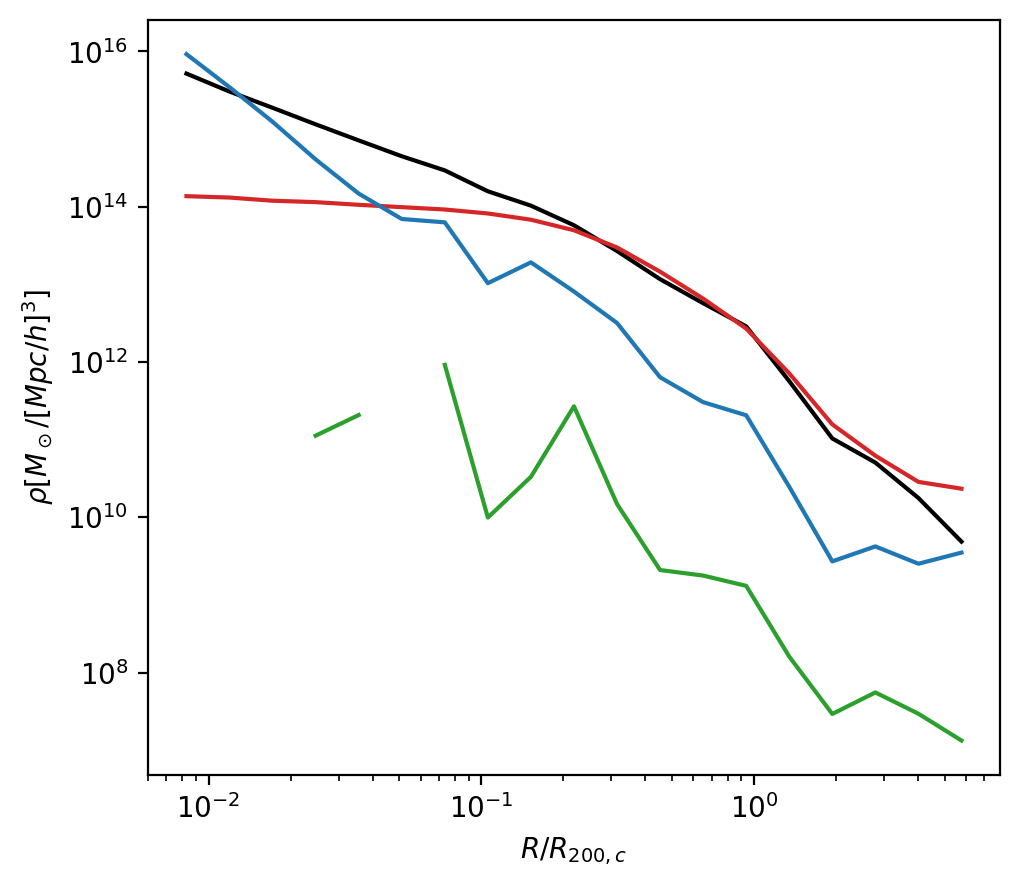

In [88]:
fig, ax = plt.subplots(dpi=200, figsize=(5.5,5))

ax.set_xscale("log")
ax.set_yscale("log")

fb = zoom_snap.Cosmology.pars['omega_baryon'] / zoom_snap.Cosmology.pars['omega_matter']
ax.plot(r_dm/r200[0], rho_dm * fb, label='DM', color='k')
ax.plot(r_gas/r200[0], rho_gas, label='Gas', color='C3')
ax.plot(r_stars/r200[0], rho_stars, label='Stars', color='C0')
ax.plot(r_bh/r200[0], rho_bh, label='BH', color='C2')

ax.set_ylabel("$\\rho[M_\\odot/[Mpc/h]^3]$")
ax.set_xlabel("$R/R_{200,c}$")